# Figure panel 6

In [1]:
options(warn=-1)

In [2]:
library_load <- suppressMessages(
    
    suppressWarnings(
        
        list(
        
            # Seurat 
            library(Seurat), 

            # TradeSeq
            library(tradeSeq),

            # CCI 
            library(CellChat), 

            # STRING
            library(STRINGdb), 
            library(igraph), 
            library(tidygraph), 
            library(ggraph), 

            # Data 
            library(tidyverse), 
            library(data.table), 

            # miloR
            library(miloR), 
            library(ggbeeswarm), 

            # Plotting 
            library(ggplot2), 
            library(ggridges), 
            library(patchwork), 
            library(cowplot), 
            library(ComplexHeatmap), 

            # Pyhton compatibility
            library(reticulate)

        )
    )
)

In [3]:
# Configure reticulate 
# use_condaenv(condaenv="p.3.10.16-FD20200109SPLENO", conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)
# py_config()

In [4]:
random_seed <- 42
set.seed(random_seed)

In [5]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20200109SPLENO")

In [6]:
# Source
source("bin/so_pl.R")
source("bin/dea_pp.R")
source("bin/dea_pl.R")
source("bin/gsea_pp.R")
source("bin/gsea_pl.R")
source("bin/tradeseq_pl.R")
source("bin/tradeseq_pp.R")

In [7]:
# Plotting Theme
source("plotting_global.R")
ggplot2::theme_set(theme_global_set(size_select=4)) # From project global source()

# Import scRNAseq data 

In [8]:
so <- readRDS("data/scRNAseq/object/pp_1.rds")
so <- NormalizeData(so)

Normalizing layer: counts



In [9]:
cnt <- GetAssayData(so[, so$celltype_low %in% c("MEP", "Proerythroblast", "Erythroblast")], assay="RNA", slot="data")

# Import erythroid lineage fitgam and make contrasts

In [10]:
tradeseq_res <- readRDS("result/lineage/tradeseq_res_2.rds")
fitgam <- tradeseq_res[["fitgam"]]
ptpg <- tradeseq_res[["ptpg"]]

In [11]:
contrast_1 <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D1")
ptpg_res_1 <- ptpg[ptpg[["contrast"]]==paste0(contrast_1, collapse=":"), ]

contrast_2 <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D3")
ptpg_res_2 <- ptpg[ptpg[["contrast"]]==paste0(contrast_2, collapse=":"), ]

contrast_3 <- c("IFNAR_fl_CpG_D1", "IFNAR_fl_CpG_D3")
ptpg_res_3 <- ptpg[ptpg[["contrast"]]==paste0(contrast_3, collapse=":"), ]



contrast_4 <- c("IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D1")
ptpg_res_4 <- ptpg[ptpg[["contrast"]]==paste0(contrast_4, collapse=":"), ]

contrast_5 <- c("IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D3")
ptpg_res_5 <- ptpg[ptpg[["contrast"]]==paste0(contrast_5, collapse=":"), ]

contrast_6 <- c("IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D3")
ptpg_res_6 <- ptpg[ptpg[["contrast"]]==paste0(contrast_6, collapse=":"), ]



contrast_7 <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0")
ptpg_res_7 <- ptpg[ptpg[["contrast"]]==paste0(contrast_7, collapse=":"), ]

contrast_8 <- c("IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")
ptpg_res_8 <- ptpg[ptpg[["contrast"]]==paste0(contrast_8, collapse=":"), ]

contrast_9 <- c("IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
ptpg_res_9 <- ptpg[ptpg[["contrast"]]==paste0(contrast_9, collapse=":"), ]

# Get genes per group 

In [12]:
# Canonical genes
genes_diff_1 <- table(c(ptpg_res_1[ptpg_res_1$ptpg_class=="Canonical", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="Canonical", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="Canonical", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="Canonical", ]$gene))
genes_diff_1 <- names(genes_diff_1[genes_diff_1==4])
genes_diff_2 <- unique(c(ptpg_res_7[ptpg_res_7$ptpg_class!="Canonical", ]$gene, ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_ptcg <- genes_diff_1[!genes_diff_1 %in% genes_diff_2]
length(genes_ptcg)

[1] 6118

In [13]:
# D1 or D3 upregulated genes 
genes_diff_1 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene))
genes_diff_3 <- unique(c(ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_ptpg_1 <- genes_diff_1[!genes_diff_1 %in% c(genes_diff_2, genes_diff_3)]
length(genes_ptpg_1)

[1] 1120

In [14]:
# D1 or D3 downregulated genes 
genes_diff_1 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene))
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))
genes_diff_3 <- unique(c(ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_ptpg_2 <- genes_diff_1[!genes_diff_1 %in% c(genes_diff_3)]
length(genes_ptpg_2)

[1] 400

In [15]:
# D3 upregulated KO
genes_diff_1 <- ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene
genes_diff_2 <- ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene

genes_ptpg_3 <- ptpg_res_9[ptpg_res_9$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene
length(genes_ptpg_3)
sum(genes_ptpg_3 %in% genes_diff_1)
sum(genes_ptpg_3 %in% genes_diff_2)

[1] 159

[1] 62

[1] 4

In [16]:
# D3 downregulated KO
genes_diff_1 <- ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene
genes_diff_2 <- ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene

genes_ptpg_4 <- ptpg_res_9[ptpg_res_9$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene
length(genes_ptpg_4)
sum(genes_ptpg_4 %in% genes_diff_1)
sum(genes_ptpg_4 %in% genes_diff_2)

[1] 311

[1] 196

[1] 2

In [17]:
genes_diff_1 <- unique(c(ptpg_res_3[ptpg_res_3$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_6[ptpg_res_6$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene))
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene))
genes_diff_3 <- unique(c(ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))
genes_diff_4 <- unique(c(ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))


genes_ptpg_5 <-  genes_diff_1[genes_diff_1 %in% c(genes_diff_2)]
length(genes_ptpg_5)

[1] 203

In [18]:
genes_diff_1 <- unique(c(ptpg_res_3[ptpg_res_3$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_6[ptpg_res_6$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))

genes_ptpg_6 <-  genes_diff_1[genes_diff_1 %in% c(genes_ptpg_1, genes_ptpg_2)]
length(genes_ptpg_6)

[1] 128

# Gene set enrichment analysis 

## Store gene sets 

In [19]:
gene_set <- msigdbr::msigdbr(species="mouse", db_species="MM", category="M5", subcategory="GO:BP")

In [20]:
gs_genes_1 <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION|AEROBIC", gs_name, value=TRUE)) %>% pull(gene_symbol) %>% unique()
# genes_ptpg_1[genes_ptpg_1 %in% gs_genes_1] %>% print()
# genes_ptpg_2[genes_ptpg_2 %in% gs_genes_1] %>% print()
# genes_ptpg_3[genes_ptpg_3 %in% gs_genes_1] %>% print()
# genes_ptpg_4[genes_ptpg_4 %in% gs_genes_1] %>% print()

In [21]:
gs_genes_2 <- gene_set %>% dplyr::filter(gs_name %in% grep("GLYCOLYTIC", gs_name, value=TRUE)) %>% pull(gene_symbol) %>% unique()
# genes_ptpg_1[genes_ptpg_1 %in% gs_genes_2] %>% print()
# genes_ptpg_2[genes_ptpg_2 %in% gs_genes_2] %>% print()
# genes_ptpg_3[genes_ptpg_3 %in% gs_genes_2] %>% print()
# genes_ptpg_4[genes_ptpg_4 %in% gs_genes_2] %>% print()

In [22]:
gs_genes_2 <- gene_set %>% dplyr::filter(gs_name %in% grep("GOBP_CELL_CYCLE_G1_S_PHASE_TRANSITION", gs_name, value=TRUE)) %>% pull(gene_symbol) %>% unique()
# genes_ptpg_1[genes_ptpg_1 %in% gs_genes_2] %>% print()
# genes_ptpg_2[genes_ptpg_2 %in% gs_genes_2] %>% print()
# genes_ptpg_3[genes_ptpg_3 %in% gs_genes_2] %>% print()
# genes_ptpg_4[genes_ptpg_4 %in% gs_genes_2] %>% print()

In [23]:
gs_genes_2 <- gene_set %>% dplyr::filter(gs_name %in% grep("CITRATE", gs_name, value=TRUE)) %>% pull(gene_symbol) %>% unique()
# genes_ptpg_1[genes_ptpg_1 %in% gs_genes_2] %>% print()
# genes_ptpg_2[genes_ptpg_2 %in% gs_genes_2] %>% print()
# genes_ptpg_3[genes_ptpg_3 %in% gs_genes_2] %>% print()
# genes_ptpg_4[genes_ptpg_4 %in% gs_genes_2] %>% print()

# Genes set enrichment analysis on lineage level 

In [24]:
gsea_pt <- function(ptpg_res, category="M5", subcategory="GO:BP") {

    padj_min <- min(ptpg_res[ptpg_res$p_val_adj_wald!=0, ]$p_val_adj_wald)
    
    ptpg_res <- ptpg_res %>% dplyr::mutate(p_val_adj_wald=ifelse(p_val_adj_wald==0, padj_min, p_val_adj_wald)) %>%dplyr::mutate(score=sign(log2FC_wilcox)*-log10(p_val_adj_wald)) %>% na.omit()

    # Ranks
    ranks <- ptpg_res$score
    names(ranks) <- ptpg_res$gene
    ranks <- ranks[order(ranks)]
    ranks <- rev(ranks)
    
    # Gene sets
    gene_set <- msigdbr::msigdbr(species="mouse", db_species="MM", category=category, subcategory=subcategory)
    gene_set <- split(gene_set, x=gene_set$gene_symbol, f=gene_set$gs_name)

    # Retain only pathways that overlap with result lsit
    gene_set_filter <- lapply(gene_set, function(x) {sum(names(ranks) %in% x)>=1})
    gene_set <- gene_set[unlist(gene_set_filter)]
    
    gsea_pt_res <- fgsea::fgsea(
            
        pathways=gene_set,
        stats=ranks,
        minSize=1,
        maxSize=Inf
    
    ) %>% na.omit() %>% dplyr::arrange(NES)

    return(gsea_pt_res)
        
}

## Response pathways 

In [25]:
gsea_pt_res_1 <- gsea_pt(ptpg_res_1) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_1 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d1_vs_ctl_cg_m5_gobp.xlsx")

In [26]:
gsea_pt_res_2 <- gsea_pt(ptpg_res_2) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_2 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d3_vs_ctl_cg_m5_gobp.xlsx")

In [27]:
gsea_pt_res_4 <- gsea_pt(ptpg_res_4) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_4 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d1_vs_ctl_ko_m5_gobp.xlsx")

In [28]:
gsea_pt_res_5 <- gsea_pt(ptpg_res_5) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_5 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d3_vs_ctl_ko_m5_gobp.xlsx")

In [29]:
pathway_select <- c(
    
    "GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY", 
    "GOBP_RESPONSE_TO_TYPE_I_INTERFERON", 
    "GOBP_RESPONSE_TO_TYPE_II_INTERFERON",    
    "GOBP_INFLAMMASOME_MEDIATED_SIGNALING_PATHWAY", 
    "GOBP_CANONICAL_NF_KAPPAB_SIGNAL_TRANSDUCTION"

)

In [30]:
gsea_pt_res <- rbind(
    
    gsea_pt_res_1 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_CpG_D1", "IFNAR_fl_Baseline_D0"), dpi="D1"), 
    gsea_pt_res_2 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_CpG_D3", "IFNAR_fl_Baseline_D0"), dpi="D3"), 
    gsea_pt_res_4 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_LysM_cre_Baseline_D0"), dpi="D1"), 
    gsea_pt_res_5 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_LysM_cre_CpG_D3", "IFNAR_fl_LysM_cre_Baseline_D0"), dpi="D3")
    
) %>% 
    dplyr::mutate(pval=ifelse(pval>0.01, 1, padj)) %>% 
    dplyr::mutate(score=-sign(NES)*log(pval)) %>% 
    dplyr::mutate(pathway=factor(pathway, levels=rev(pathway_select))) %>%
    dplyr::mutate(pathway=factor(gsub("HALLMARK", "", pathway), levels=gsub("HALLMARK", "", levels(pathway)))) %>%
    dplyr::mutate(pathway=factor(gsub("^_", "", pathway), levels=gsub("^_", "", levels(pathway)))) %>% 
    dplyr::mutate(pathway=factor(gsub("_", " ", pathway), levels=gsub("_", " ", levels(pathway)))) %>% 
    dplyr::mutate(fill=factor(fill, levels=rev(c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3"))))

In [31]:
options(repr.plot.height=5, repr.plot.width=20)

gsea_pt_res_p <- ggplot(gsea_pt_res, aes(x=score, y=pathway, fill=fill)) + 
    geom_bar(position=position_dodge(width=0.8), stat="identity", width=0.8, color="black", linewidth=0.1) + 
    facet_grid(~dpi) + 
    scale_fill_manual(values=c(color$sample_group, "n.s."="#7f7f7f")) + theme_global_set(4)

In [32]:
pdf("result/figures/1_scRNAseq/panel_6/gsea_response.pdf", width=10, height=3)

set_height <- length(pathway_select)*0.25
set_width <- 1

gsea_pt_res_p + ggh4x::force_panelsizes(cols=unit(set_width, "cm"), total_height=unit(set_height, "cm"))

dev.off()

pdf 
  2

## Genotype pathways

In [41]:
gsea_pt_res_7 <- gsea_pt(ptpg_res_7) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_7 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_ko_vs_cg_ctl_m5_gobp.xlsx")

In [42]:
gsea_pt_res_8 <- gsea_pt(ptpg_res_8) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_8 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_ko_vs_cg_d1_m5_gobp.xlsx")

In [43]:
gsea_pt_res_9 <- gsea_pt(ptpg_res_9) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_9 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_ko_vs_cg_d3_m5_gobp.xlsx")

In [44]:
pathway_select <- c(

    "GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY", 
    "GOBP_RESPONSE_TO_TYPE_I_INTERFERON", 
    "GOBP_RESPONSE_TO_TYPE_II_INTERFERON",    
    "GOBP_INFLAMMASOME_MEDIATED_SIGNALING_PATHWAY", 
    "GOBP_CANONICAL_NF_KAPPAB_SIGNAL_TRANSDUCTION"
    
)

In [45]:
gsea_pt_res <- rbind(

    # gsea_pt_res_7 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_Baseline_D0"), dpi="Ctl"),
    gsea_pt_res_8 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D1"), dpi="D1"), 
    gsea_pt_res_9 %>% dplyr::filter(pathway %in% pathway_select) %>% dplyr::mutate(fill=ifelse(sign(NES)==+1, "IFNAR_fl_LysM_cre_CpG_D3", "IFNAR_fl_CpG_D3"), dpi="D3")
    
) %>% 
    dplyr::mutate(pval=ifelse(padj>0.01, 1, pval)) %>% 
    dplyr::mutate(score=-sign(NES)*log(pval)) %>% 
    dplyr::mutate(pathway=factor(pathway, levels=rev(pathway_select))) %>%
    dplyr::mutate(pathway=factor(gsub("GOBP", "", pathway), levels=gsub("GOBP", "", levels(pathway)))) %>%
    dplyr::mutate(pathway=factor(gsub("^_", "", pathway), levels=gsub("^_", "", levels(pathway)))) %>% 
    dplyr::mutate(pathway=factor(gsub("_", " ", pathway), levels=gsub("_", " ", levels(pathway))))

In [50]:
gsea_pt_res_p <- ggplot(gsea_pt_res, aes(x=score, y=pathway, fill=fill)) + 
    geom_bar(position=position_dodge(width=0.8), stat="identity", width=0.8, color="black", linewidth=0.1) + scale_x_continuous(breaks=c(-30, 0, +30), limits=c(-31, +31)) + 
    facet_grid(~dpi) + 
    scale_fill_manual(values=c(color$sample_group, "n.s."="#7f7f7f")) + theme_global_set(4)

In [51]:
pdf("result/figures/1_scRNAseq/panel_6/gsea_genotype.pdf", width=10, height=3)

set_height <- length(pathway_select)*0.25
set_width <- 1

gsea_pt_res_p + ggh4x::force_panelsizes(cols=unit(set_width, "cm"), total_height=unit(set_height, "cm"))

dev.off()

pdf 
  2

## D1 vs D3 pathways 

In [40]:
gsea_pt_res_3 <- gsea_pt(ptpg_res_3) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_3 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d1_vs_d3_cg_m5_gobp.xlsx")

In [41]:
gsea_pt_res_6 <- gsea_pt(ptpg_res_6) %>% dplyr::arrange(NES)
openxlsx::write.xlsx(gsea_pt_res_6 %>% dplyr::filter(padj<=0.05), "result/gsea/scRNAseq/gsea_pt_d1_vs_d3_ko_m5_gobp.xlsx")

# Gene regulatory network analysis 

In [42]:
auc_mtx_1 <- read.csv("result/scenic/scRNAseq/res_1/auc_mtx.csv", row.names=1) %>% t()
rownames(auc_mtx_1) <- gsub("\\.", "", rownames(auc_mtx_1))

In [43]:
so_1 <- subset(so, subset=cell_id %in% colnames(auc_mtx_1))
auc_mtx_1 <- auc_mtx_1[, colnames(so_1)]
so_1[["AUC"]] <- CreateAssayObject(data=auc_mtx_1[, colnames(so_1)], min.cells=0, min.features=0)

In [44]:
sampale_group <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
celltype_low <- c("MEP", "Proerythroblast", "Erythroblast")

In [45]:
auc_mat <- GetAssayData(so_1, assay="AUC", slot="data")

In [46]:
mat <- lapply(sampale_group, function(i) {

    mat_i <- list(
        
        auc_mat[, (so_1$sample_group==i & so_1$celltype_low==celltype_low[1])] %>% rowMeans() %>% data.frame(auc=.) %>% dplyr::mutate(celltype_low=celltype_low[1]) %>% tibble::rownames_to_column("module"),
        auc_mat[, (so_1$sample_group==i & so_1$celltype_low==celltype_low[2])] %>% rowMeans() %>% data.frame(auc=.) %>% dplyr::mutate(celltype_low=celltype_low[2]) %>% tibble::rownames_to_column("module"),
        auc_mat[, (so_1$sample_group==i & so_1$celltype_low==celltype_low[3])] %>% rowMeans() %>% data.frame(auc=.) %>% dplyr::mutate(celltype_low=celltype_low[3]) %>% tibble::rownames_to_column("module")
    
    )

    mat_i <- do.call(rbind, mat_i) %>% dplyr::mutate(sample_group=i)

    return(mat_i)

    
}
      ) %>% do.call(rbind, .)

In [47]:
rss_hm <- function(mat, row_split=NULL, row_labels=NULL, col_split=NULL, col_label=NULL, cluster_rows=TRUE, use_raster=FALSE, scale_width=1, scale_height=1,  fontsize_select=1) {

    # Set font size 
    fontsize <- list(size_1=c(16, 18), size_2=c(6, 8))[[fontsize_select]]
    fontsize_scale <- c(1, 0.5)[[fontsize_select]]

    color_ramp_mat <- viridis::mako(3)
    breaks_mat <- seq(-2, +2, na.rm=TRUE, length.out=3)
    color_function_mat <- circlize::colorRamp2(breaks_mat, color_ramp_mat) 

    # Set width and height 
    width <- scale_width*fontsize_scale*5*ncol(mat) + (length(unique(col_split))-1)
    height <- scale_height*fontsize_scale*5*nrow(mat) + (length(unique(row_split))-1)

    hm <- Heatmap(
        
        mat,
    
        col=color_function_mat, 
        na_col="#d3d3d3", 
        
        width=width*unit(1, "mm"),
        height=height*unit(1, "mm"),
    
        row_title_gp=gpar(fontsize=fontsize[1], fontface="bold"), 

        # column_title=col_label, 
        column_title_gp=gpar(fontsize=fontsize[1], fontface="bold"), 

        row_names_gp=gpar(fontsize=fontsize[1], fontface="plain"), 
        column_names_gp=gpar(fontsize=fontsize[1], fontface="plain"), 
        
        cluster_rows=cluster_rows,
        cluster_row_slices=FALSE, 
        show_row_names=TRUE,
        row_names_side="left",
        row_split=row_split, 
        row_labels=row_labels, 
        row_gap=unit(1, "mm"),

        cluster_columns=FALSE,
        column_split=col_split, 
        show_column_names=TRUE, 
        column_gap=unit(1, "mm"), 
    
        show_heatmap_legend=TRUE, 

        heatmap_legend_param=list(title="Count", title_gp=gpar(fontsize=fontsize[1], fontface="plain"), labels_gp=gpar(fontsize=fontsize[1]), legend_height=unit(fontsize_scale*15, "mm"), grid_width=unit(fontsize_scale*3, "mm")), 
        
        border=TRUE, 
        rect_gp=gpar(col="black", lwd=unit(fontsize_scale*2*0.6667, "pt")), 
        border_gp=gpar(col="black", lwd=unit(fontsize_scale*3*0.6667, "pt")), 

        use_raster=use_raster, raster_by_magick=TRUE, raster_resize_mat=mean
        

    )

    return(hm)
}

## Stress response module 

In [48]:
mat_1 <- mat %>%  
    dplyr::select(celltype_low, module, sample_group, auc) %>% 
    dplyr::group_by(module) %>% dplyr::mutate(auc=as.numeric(scale(auc, scale=TRUE, center=TRUE))) %>% 
    tidyr::pivot_wider(names_from=sample_group, values_from=auc) %>% 
    dplyr::filter(
        
        (celltype_low=="MEP" & module %in% c("Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb")) | 
        (celltype_low=="Proerythroblast" & module %in% c("Stat1", "Stat2", "Stat3", "Irf1", "Irf7",  "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb")) | 
        (celltype_low=="Erythroblast" & module %in% c("Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb"))
        
    ) %>% dplyr::ungroup()

In [49]:
row_split <- factor(mat_1$celltype_low, levels=c("MEP", "Proerythroblast", "Erythroblast"))
row_labels <- mat_1$module
col_split <- c("Ctl", "Ctl", "D1", "D1", "D3", "D3")

In [50]:
mat_1 <- mat_1 %>% dplyr::select(-celltype_low, -module) 
mat_1 <- mat_1[, c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [51]:
pdf("result/figures/1_scRNAseq/panel_6/auc_stress_module.pdf", width=3, height=6)

rss_hm(mat_1, row_split=row_split, row_labels=row_labels, col_split=col_split, fontsize_select=2)

dev.off()

pdf 
  2

## Erythroid development module 

In [52]:
mat_1 <- mat %>%  
    dplyr::select(celltype_low, module, sample_group, auc) %>% 
    dplyr::filter(
        
        (celltype_low=="MEP" & module %in% c("Sox4", "Gata2", "Ikzf2", "Spi1", "Myb", "Myc")) | 
        (celltype_low=="Proerythroblast" & module %in% c("Gata1", "Ikzf1", "Mbd2")) | 
        (celltype_low=="Erythroblast" & module %in% c("Sox6", "Tal1", "Klf3", "E2f2"))
        
    ) %>% dplyr::ungroup() %>%
    dplyr::group_by(module) %>% dplyr::mutate(auc=as.numeric(scale(auc, scale=TRUE, center=TRUE))) %>% 
    tidyr::pivot_wider(names_from=sample_group, values_from=auc) %>% 

    dplyr::mutate(module=factor(module, levels=c("Sox4", "Gata2", "Ikzf2", "Spi1", "Myb", "Myc", "Gata1", "Ikzf1", "Mbd2", "Sox6", "Tal1", "Klf3", "E2f2"))) %>% dplyr::arrange(module) %>% dplyr::ungroup()
    

In [53]:
row_split <- factor(mat_1$celltype_low, levels=c("MEP", "Proerythroblast", "Erythroblast"))
row_labels <- mat_1$module
col_split <- c("Ctl", "Ctl", "D1", "D1", "D3", "D3")

In [54]:
mat_1 <- mat_1 %>% dplyr::select(-celltype_low, -module) 
mat_1 <- mat_1[, c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [55]:
pdf("result/figures/1_scRNAseq/panel_6/auc_erythroid_tf.pdf", width=3, height=3)

rss_hm(mat_1, row_split=row_split, row_labels=row_labels, col_split=col_split, fontsize_select=2)

dev.off()

pdf 
  2

## Bar plot differential AUC

In [56]:
grn_wilcox_res <- rbind(

    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d1_vs_ifnar_fl_cpg_d1.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D1"), 
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d3_vs_ifnar_fl_cpg_d3.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D3")

)

In [57]:
celltype_select <- c("MEP", "Proerythroblast", "Erythroblast")
module_select <- c("Sox4", "Runx1", "Etv6", "Myb", "Foxp1", "Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Jun", "Junb", "Jund", "Fos", "Fosb")

In [58]:
data <- grn_wilcox_res %>% 
    dplyr::filter(module %in% module_select, celltype_low %in% celltype_select) %>% 
    dplyr::mutate(p_val_adj=ifelse(p_val_adj>0.01, 1, p_val_adj)) %>% 
    dplyr::mutate(score=-sign(avg_log2FC)*log10(p_val_adj)) %>% dplyr::arrange(score) %>%
    dplyr::mutate(fill=ifelse(sign(score)==+1, "IFNAR_fl_LysM_cre_CpG_D3", "IFNAR_fl_CpG_D3")) %>% 
    dplyr::mutate(celltype_low=factor(celltype_low, levels=celltype_select), module=factor(module, levels=rev(module_select)))

In [59]:
grn_p_1 <- ggplot(data, aes(x=score, y=module, fill=fill)) + 
    geom_bar(stat="identity", width=0.8, color="black", linewidth=0.1) + 
    facet_grid(celltype_low~dpi) + 
    scale_fill_manual(values=c(color$sample_group, "n.s."="#7f7f7f")) + theme_global_set(4)

In [60]:
pdf("result/figures/1_scRNAseq/panel_6/auc_diff_d1_and_d3.pdf", width=4, height=8)

set_height <- 0.20 * length(module_select) * length(celltype_select)
set_width <- 1.00

grn_p_1 + ggh4x::force_panelsizes(cols=unit(set_width, "cm"), total_height=unit(set_height, "cm"))

dev.off()

pdf 
  2

## Point plot differential AUC

In [61]:
celltype_select <- c("MEP", "Proerythroblast", "Erythroblast")

## D1 or D3 vs Ctl

In [62]:
grn_wilcox_res <- rbind(

    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_cpg_d1_vs_ifnar_fl_baseline_d0.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D1", genotype="+/+") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D1")), 
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_cpg_d3_vs_ifnar_fl_baseline_d0.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D3", genotype="+/+") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D3")),  
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d1_vs_ifnar_fl_lysm_cre_baseline_d0.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D1", genotype="cre/+") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D1")), 
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d3_vs_ifnar_fl_lysm_cre_baseline_d0.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D3", genotype="cre/+") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D3"))

) %>% 
    dplyr::filter(celltype_low %in% celltype_select) %>% dplyr::mutate(celltype_low=factor(celltype_low, levels=celltype_select)) %>% 
    dplyr::mutate(sample_group=ifelse(p_val_adj<=0.01 & abs(avg_log2FC)>=0.25 & module %in% ptpg$gene, sample_group, NA)) %>% 
    dplyr::mutate(label=ifelse(p_val_adj<=0.01 & abs(avg_log2FC)>=0.25 & module %in% ptpg$gene & module %in% c("Sox4", "Runx1", "Etv6", "Myb", "Foxp1", "Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Jun", "Junb", "Jund", "Fos", "Fosb"), module, NA))

In [63]:
grn_wilcox_res_p <- ggplot(grn_wilcox_res, aes(x=avg_auc_1, y=avg_auc_2, color=sample_group, label=label)) + 
    geom_point(size=0.5, shape=19) + 
    geom_abline(intercept=0, slope=1, linetype="dashed", linewidth=0.5, color="black") + 
    facet_grid(celltype_low ~ dpi + genotype, scales="free", axes="all", axis.labels="margins") + 
    scale_color_manual(values=color$sample_group) +
    scale_x_continuous(breaks=c(0.00, 0.05, 0.10, 0.15), limits=c(0, 0.15)) + scale_y_continuous(breaks=c(0.00, 0.05, 0.10, 0.15), limits=c(0, 0.15)) + 
    ggrepel::geom_text_repel(segment.color="black", force=10, force_pull=1, max.overlaps=getOption("ggrepel.max.overlaps", default=100), size=2, alpha=1, guide="none", segment.size=0.1, color="black", min.segment.length=0.1, fontface="italic") + 
    theme(aspect.ratio=1) 

In [64]:
pdf("result/figures/1_scRNAseq/panel_6/auc_diff_point_d1_or_d3_vs_ctl.pdf", width=6, height=4)

set_height <- 2 * length(celltype_select)
set_width <- 2

grn_wilcox_res_p + ggh4x::force_panelsizes(cols=unit(set_width, "cm"), total_height=unit(set_height, "cm"))

dev.off()

pdf 
  2

## KO vs CG

In [65]:
grn_wilcox_res <- rbind(

    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_baseline_d0_vs_ifnar_fl_baseline_d0.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="Ctl") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0")), 
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d1_vs_ifnar_fl_cpg_d1.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D1") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")), 
    readRDS("result/scenic/scRNAseq/auc_wilcox_ifnar_fl_lysm_cre_cpg_d3_vs_ifnar_fl_cpg_d3.rds") %>% do.call(rbind, .) %>% dplyr::mutate(dpi="D3") %>% dplyr::mutate(sample_group=ifelse(sign(avg_log2FC)==-1, "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3"))

) %>% 
    dplyr::filter(celltype_low %in% celltype_select) %>% dplyr::mutate(celltype_low=factor(celltype_low, levels=celltype_select)) %>% 
    dplyr::mutate(sample_group=ifelse(p_val_adj<=0.01 & abs(avg_log2FC)>=0.25 & module %in% ptpg$gene, sample_group, NA)) %>% 
    dplyr::mutate(label=ifelse(p_val_adj<=0.01 & abs(avg_log2FC)>=0.25 & module %in% ptpg$gene, module, NA))

## Count target gene heat map 

In [66]:
tf_select <- c("Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb")

In [67]:
reg <- read.csv("result/scenic/scRNAseq/res_1/reg.csv", row.names=1, skip=1)
colnames(reg) <- c("TF", "target_genes")

In [68]:
genes_diff_1 <- table(c(ptpg_res_1[ptpg_res_1$ptpg_class=="Canonical", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="Canonical", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="Canonical", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="Canonical", ]$gene))
genes_diff_1 <- names(genes_diff_1[genes_diff_1==4])
genes_diff_2 <- unique(c(ptpg_res_7[ptpg_res_7$ptpg_class!="Canonical", ]$gene, ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_ptcg <- data.frame(target_genes=genes_diff_1[!genes_diff_1 %in% genes_diff_2], group="Canonical")

In [69]:
genes_ptpg_1 <- data.frame(target_genes=unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene)), group="D1_UP")
genes_ptpg_2 <- data.frame(target_genes=unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene)), group="D1_DOWN")
genes_ptpg_3 <- data.frame(target_genes=unique(c(ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene)), group="D3_UP")
genes_ptpg_4 <- data.frame(target_genes=unique(c(ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene)), group="D3_DOWN")

In [70]:
do.call(rbind, list(genes_ptcg, genes_ptpg_1, genes_ptpg_2, genes_ptpg_3, genes_ptpg_4)) %>% dplyr::left_join(., reg, by=join_by(target_genes)) %>% 
    dplyr::filter(TF %in% tf_select) %>% dplyr::mutate(TF=factor(TF, levels=tf_select)) %>% 
    dplyr::group_by(group, TF) %>% dplyr::summarise(n=n()) %>% 
    tidyr::pivot_wider(names_from=TF, values_from=n, values_fill=0)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


group,Stat1,Stat2,Stat3,Irf1,Irf7,Atf3,Jun,Junb,Jund,Fos,Fosb
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Canonical,546,90,63,156,82,8,8,19,29,8,16
D1_DOWN,12,7,3,7,2,0,0,1,1,0,0
D1_UP,384,180,147,230,151,7,8,13,7,3,1
D3_DOWN,19,5,5,9,3,0,0,1,1,0,0
D3_UP,436,179,149,266,152,15,23,29,8,6,7


# Density plot 

In [71]:
so <- AddMetaData(so, read.csv("result/pseudotime/ery_dpt.csv", row.names=1))

In [72]:
# Min max scale per condition 
data <- so@meta.data

minmax_scale <- function(x) {(x - min(x, na.rm=TRUE)) / (max(x, na.rm=TRUE) - min(x, na.rm=TRUE))}
data <- data %>% dplyr::filter(!is.na(dpt_pseudotime)) %>% dplyr::group_by(sample_group) %>% dplyr::mutate(dpt_pseudotime=minmax_scale(dpt_pseudotime)) %>% dplyr::ungroup() %>% as.data.frame() 

In [73]:
dpt_range <- range(data$dpt_pseudotime, na.rm=TRUE)
color_gradient <- c(color$celltype_low["MEP"], color$celltype_low["MEP"], color$celltype_low["Proerythroblast"], color$celltype_low["Proerythroblast"], color$celltype_low["Erythroblast"], color$celltype_low["Erythroblast"])
breaks_gradient <- scales::rescale(c(0, 0.4, 0.4, 0.8, 0.8, 1), from=dpt_range)

## Sample group 

In [74]:
rp_1 <- lapply(c("D0", "D1", "D3"), function(i) {

    ggplot(data[data$dpi==i, ], aes(x=dpt_pseudotime, y=dpi)) +
  
        ggridges::geom_density_ridges_gradient(aes(fill=after_stat(x)), scale=1, rel_min_height=0, from=0, to=1, panel_scaling=FALSE, bandwidth=0.05, linewidth=unit(0.5/2.141959, "pt")) +
        scale_fill_gradientn(colours=color_gradient, values=breaks_gradient, limits=dpt_range, na.value="#000000", guide="none") + 
        facet_grid(~genotype) + 
        scale_x_continuous(breaks=c(0.0, 0.5, 1.0), labels=c("0.0", "0.5", "1.0"), limits=c(0, 1), expand=c(0, 0)) +
        scale_y_discrete(expand=c(0, 0)) +
        theme_global_set(4) + 
        theme(strip.text=element_blank(), strip.background = element_blank())
    
}
      )

In [75]:
rp_1 <- lapply(rp_1, function(x) {x %>% egg::set_panel_size(., width=unit(2.0, "cm"), height=unit(0.75, "cm"))})

In [76]:
pdf("result/figures/1_scRNAseq/panel_6/rp_celltype_low.pdf", width=3, height=3)

gridExtra::grid.arrange(

    rp_1[[1]], rp_1[[2]], rp_1[[3]], ncol=1
        
)

dev.off()

pdf 
  2

## Merged 

In [77]:
rp_1 <- ggplot(data %>% dplyr::mutate(merge="merge"), aes(x=dpt_pseudotime, y=merge)) +
  
        ggridges::geom_density_ridges_gradient(aes(fill=after_stat(x)), scale=1, rel_min_height=0, from=0, to=1, panel_scaling=FALSE, bandwidth=0.05, linewidth=unit(0.5/2.141959, "pt")) +
        scale_fill_gradientn(colours=color_gradient, values=breaks_gradient, limits=dpt_range, na.value="#000000", guide="none") + 
        scale_x_continuous(breaks=c(0.0, 0.5, 1.0), labels=c("0.0", "0.5", "1.0"), limits=c(0, 1), expand=c(0, 0)) +
        scale_y_discrete(expand=c(0, 0)) +
        theme_global_set(4) + 
        theme(strip.text=element_blank(), strip.background = element_blank())

In [78]:
rp_1 <- rp_1 %>% egg::set_panel_size(., width=unit(2.0, "cm"), height=unit(0.75, "cm"))

In [79]:
pdf("result/figures/1_scRNAseq/panel_6/rp_celltype_low_merge.pdf", width=3, height=3)

gridExtra::grid.arrange(

    rp_1

)

dev.off()

pdf 
  2

# Pruned graph TF and target genes 

In [80]:
reg <- read.csv("result/scenic/scRNAseq/res_1/reg.csv", row.names=1, skip=1)
colnames(reg) <- c("TF", "target_genes")

# Transcription factor heatmap of smoothed expression 

In [81]:
# tf <- c("Sox4", "Gata2", "Ikzf2", "Spi1", "Myb", "Myc", "Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb", "Gata1", "Klf1", "Klf3", "E2f2", "Tal1")
tf <- c("Stat1", "Stat2", "Stat3", "Irf1", "Irf7", "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb")

## PTCG D1 and D3 and Ctl 

In [82]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [83]:
genes_diff_1 <- table(c(ptpg_res_1[ptpg_res_1$ptpg_class=="Canonical", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="Canonical", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="Canonical", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="Canonical", ]$gene))
genes_diff_1 <- names(genes_diff_1[genes_diff_1==4])
genes_diff_2 <- unique(c(ptpg_res_7[ptpg_res_7$ptpg_class!="Canonical", ]$gene, ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_diff <- genes_diff_1[!genes_diff_1 %in% genes_diff_2]
length(genes_diff_1)
length(genes_diff_2)
length(genes_diff)

[1] 6279

[1] 521

[1] 6118

In [84]:
sum(gs_genes_1 %in% genes_diff)

[1] 111

In [85]:
pt_split_ptpg <- pt_split(fitgam, genes_diff, contrast_vec)

In [86]:
tf_tg_mat_ptpg <- reg[reg$target_genes %in% genes_diff & reg$TF %in% ptpg$gene, ]
tf_tg_mat_ptpg <- tf_tg_pp(tf_tg_mat_ptpg)
tf_tg_mat_ptpg <- tf_tg_prune(tf_tg_mat_ptpg, pt_split_ptpg, tf_ratio=0, tf_sum=0, tf_fill=TRUE)
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf[tf %in% colnames(tf_tg_mat_ptpg)]]

In [87]:
tf_fill <- setdiff(tf, colnames(tf_tg_mat_ptpg))
tf_tg_mat_ptpg[, tf_fill] <- 0
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf, drop=FALSE]

In [88]:
pt_tf_hm_1 <- pt_tf_hm(tf_tg_mat_ptpg, row_split=pt_split_ptpg, height=100, fontsize_select=2, cluster_rows=FALSE, cluster_columns=FALSE, use_raster=TRUE)
pt_hm_1 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_Baseline_D0", contrast_vec, 50, color_mat[1], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)
pt_hm_2 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_Baseline_D0", contrast_vec, 50, color_mat[2], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)
pt_hm_3 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D1", contrast_vec, 50, color_mat[3], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)
pt_hm_4 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D1", contrast_vec, 50, color_mat[4], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)
pt_hm_5 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D3", contrast_vec, 50, color_mat[5], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)
pt_hm_6 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D3", contrast_vec, 50, color_mat[6], row_split=pt_split_ptpg, width=0.75, height=100, fontsize_select=2, use_raster=TRUE)

In [89]:
row_genes <- c(

    "Meis1", "Klf1", "Tal1", "Gata1", "Gata2", # Transcription factors 
    "Mki67", "Top2a", # Proliferation 
    "Pkm", # Glycolysis
    "Pdk1", # Glycolysis/aerobic metabolism
    "Hif1a", "Ldha", # Glycolysis/anaerboic metabolism
    "Atp5a1", "Atp5b", # Oxidative phosphorylation 
    "Sod2", # ROS detoxifiyer
    "G6pdx", "Pgd", # PP
    "Cpt1a", "Acadl", # b-oxidatse
    "Mtor", "Rptor", "Rheb",  # mTOR pathwy
    "Tfam", "Ssbp1", "Polg", # Mitochondrial maintainance
    "Bnip3l", # Mitochondrial removal 
    "Dnmt1", "Dnmt3b", "Tet2", "Tet3", # Epigenetics
    "Alas2", "Ncoa4", # Heme metabolism 
    "Icam4", "Epor", "Tfrc" # Receptor

)

row_genes[!row_genes %in% names(pt_split_ptpg)]
row_genes <- row_genes[row_genes %in% names(pt_split_ptpg)]

row_anno <- rowAnnotation(
    
    labels=anno_mark(
        
        at=which(rownames(pt_tf_hm_1@matrix) %in% row_genes),
        labels=rownames(pt_tf_hm_1@matrix)[which(rownames(pt_tf_hm_1@matrix) %in% row_genes)],
        side="left", 
        labels_gp=gpar(fontsize=6), 
        link_width=unit(3, "mm")
    
    )

)

[1] "Pkm"    "Pdk1"   "G6pdx"  "Cpt1a"  "Acadl"  "Mtor"   "Bnip3l"

In [90]:
pdf("result/figures/1_scRNAseq/panel_6/hm_tf_ptcg_d1_and_d3_and_ctl.pdf", width=10, height=10)

draw(row_anno + pt_tf_hm_1 + pt_hm_1 + pt_hm_2 + pt_hm_3 + pt_hm_4 + pt_hm_5 + pt_hm_6)

dev.off()

Loading required namespace: magick



pdf 
  2

## PTPG D1 or D3 UP vs Ctl 

In [91]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [92]:
genes_diff_1 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene))
genes_diff_3 <- unique(c(ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_diff <- genes_diff_1[!genes_diff_1 %in% c(genes_diff_2, genes_diff_3)]
length(genes_diff_1)
length(genes_diff_2)
length(genes_diff_3)
length(genes_diff)

[1] 1422

[1] 456

[1] 514

[1] 1120

In [93]:
pt_split_ptpg <- pt_split(fitgam, genes_diff, contrast_vec)

In [94]:
tf_tg_mat_ptpg <- reg[reg$target_genes %in% genes_diff & reg$TF %in% ptpg$gene, ]
tf_tg_mat_ptpg <- tf_tg_pp(tf_tg_mat_ptpg)
tf_tg_mat_ptpg <- tf_tg_prune(tf_tg_mat_ptpg, pt_split_ptpg, tf_ratio=0, tf_sum=0, tf_fill=TRUE)
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf[tf %in% colnames(tf_tg_mat_ptpg)]]

In [95]:
tf_fill <- setdiff(tf, colnames(tf_tg_mat_ptpg))
tf_tg_mat_ptpg[, tf_fill] <- 0
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf, drop=FALSE]

In [96]:
pt_tf_hm_1 <- pt_tf_hm(tf_tg_mat_ptpg, row_split=pt_split_ptpg, height=50, fontsize_select=2, cluster_rows=FALSE, cluster_columns=FALSE, use_raster=TRUE)
pt_hm_1 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_Baseline_D0", contrast_vec, 50, color_mat[1], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_2 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_Baseline_D0", contrast_vec, 50, color_mat[2], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_3 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D1", contrast_vec, 50, color_mat[3], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_4 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D1", contrast_vec, 50, color_mat[4], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_5 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D3", contrast_vec, 50, color_mat[5], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_6 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D3", contrast_vec, 50, color_mat[6], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)

In [97]:
row_genes <- c(

    "Myd88", # TLR 
    "Lyl1",
    "Serpina3g",  # Protect from cell death. Especially Serpina3g has konwn roles in erythropoiesis 
    "Cd9", 
    # "Atp10a", # AP4 flippase
    "G6pdx", # PPP
    "Got1", "Acot9",  # Fatty acid metabolism 
    "Ldlrap1", "Lrp8", # LDL receptor "Ffar2"
    "Pfkp", # Glucose
    "Scly" # Selenium metabolism 
    
)

row_genes[!row_genes %in% rownames(pt_tf_hm_1@matrix)]
row_genes <- row_genes[row_genes %in% rownames(pt_tf_hm_1@matrix)]

row_anno <- rowAnnotation(
    
    labels=anno_mark(
        at=which(rownames(pt_tf_hm_1@matrix) %in% row_genes),
        labels=rownames(pt_tf_hm_1@matrix)[which(rownames(pt_tf_hm_1@matrix) %in% row_genes)],
        side="left", 
        labels_gp=gpar(fontsize=6), 
        link_width=unit(3, "mm")
    
    )

)

character(0)

In [98]:
pdf("result/figures/1_scRNAseq/panel_6/hm_tf_ptpg_d1_or_d3_up_vs_ctl.pdf", width=10, height=6)

draw(row_anno + pt_tf_hm_1 + pt_hm_1 + pt_hm_2 + pt_hm_3 + pt_hm_4 + pt_hm_5 + pt_hm_6)

dev.off()

pdf 
  2

In [99]:
# lp_1 <- lapply(names(pt_split_ptpg), function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
# lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
# lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [100]:
# pdf("result/figures/1_scRNAseq/panel_6/lp_ptpg_d1_or_d3_up_vs_ctl.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

# grid::grid.draw(lp_1)

# dev.off()

## PTPG D1 or D3 DOWN vs Ctl 

In [101]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [102]:
genes_diff_1 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_Baseline_D0", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_Baseline_D0", ]$gene))
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene, ptpg_res_2[ptpg_res_2$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene, ptpg_res_5[ptpg_res_5$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene))
genes_diff_3 <- unique(c(ptpg_res_8[ptpg_res_8$ptpg_class!="Canonical", ]$gene, ptpg_res_9[ptpg_res_9$ptpg_class!="Canonical", ]$gene))
genes_diff <- genes_diff_1[!genes_diff_1 %in% c(genes_diff_3)]
length(genes_diff_1)
length(genes_diff_2)
length(genes_diff_3)
length(genes_diff)

[1] 456

[1] 1422

[1] 514

[1] 400

In [103]:
write.csv(data.frame(genes=genes_diff), "genes.csv")

In [104]:
pt_split_ptpg <- pt_split(fitgam, genes_diff, contrast_vec)

In [105]:
tf_tg_mat_ptpg <- reg[reg$target_genes %in% genes_diff & reg$TF %in% ptpg$gene, ]
tf_tg_mat_ptpg <- tf_tg_pp(tf_tg_mat_ptpg)
tf_tg_mat_ptpg <- tf_tg_prune(tf_tg_mat_ptpg, pt_split_ptpg, tf_ratio=0, tf_sum=0, tf_fill=TRUE)
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf[tf %in% colnames(tf_tg_mat_ptpg)]]

In [106]:
tf_fill <- setdiff(tf, colnames(tf_tg_mat_ptpg))
tf_tg_mat_ptpg[, tf_fill] <- 0
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf, drop=FALSE]

In [107]:
pt_tf_hm_1 <- pt_tf_hm(tf_tg_mat_ptpg, row_split=pt_split_ptpg, height=20, fontsize_select=2, cluster_rows=FALSE, cluster_columns=FALSE, use_raster=TRUE)
pt_hm_1 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_Baseline_D0", contrast_vec, 50, color_mat[1], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)
pt_hm_2 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_Baseline_D0", contrast_vec, 50, color_mat[2], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)
pt_hm_3 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D1", contrast_vec, 50, color_mat[3], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)
pt_hm_4 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D1", contrast_vec, 50, color_mat[4], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)
pt_hm_5 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D3", contrast_vec, 50, color_mat[5], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)
pt_hm_6 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D3", contrast_vec, 50, color_mat[6], row_split=pt_split_ptpg, width=0.75, height=20, fontsize_select=2, use_raster=TRUE)

In [108]:
row_genes <- c(

    "Mxd4", "Deptor", "Txnip", "Pdcd4", "Cox6b2", "Prkn"
    
)

row_genes <- row_genes[row_genes %in% rownames(pt_tf_hm_1@matrix)]

row_anno <- rowAnnotation(
    
    labels=anno_mark(
        at=which(rownames(pt_tf_hm_1@matrix) %in% row_genes),
        labels=rownames(pt_tf_hm_1@matrix)[which(rownames(pt_tf_hm_1@matrix) %in% row_genes)],
        side="left", 
        labels_gp=gpar(fontsize=6), 
        link_width=unit(3, "mm")
    
    )

)

In [109]:
pdf("result/figures/1_scRNAseq/panel_6/hm_tf_ptpg_d1_or_d3_down_vs_ctl.pdf", width=10, height=6)

draw(row_anno + pt_tf_hm_1 + pt_hm_1 + pt_hm_2 + pt_hm_3 + pt_hm_4 + pt_hm_5 + pt_hm_6)

dev.off()

pdf 
  2

In [110]:
# lp_1 <- lapply(names(pt_split_ptpg), function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
# lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
# lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [111]:
# pdf("result/figures/1_scRNAseq/panel_6/lp_ptpg_d1_or_d3_down_vs_ctl.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

# grid::grid.draw(lp_1)

# dev.off()

## PTPG D3 (cre/+) UP vs D3 (+/+) 

In [112]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [113]:
genes_diff <- ptpg_res_9[ptpg_res_9$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D3", ]$gene
length(genes_diff)

[1] 159

In [114]:
pt_split_ptpg <- pt_split(fitgam, genes_diff, "IFNAR_fl_LysM_cre_CpG_D3")

In [115]:
tf_tg_mat_ptpg <- reg[reg$target_genes %in% genes_diff & reg$TF %in% ptpg$gene, ]
tf_tg_mat_ptpg <- tf_tg_pp(tf_tg_mat_ptpg)
tf_tg_mat_ptpg <- tf_tg_prune(tf_tg_mat_ptpg, pt_split_ptpg, tf_ratio=0, tf_sum=0, tf_fill=TRUE)
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf[tf %in% colnames(tf_tg_mat_ptpg)]]

In [116]:
tf_fill <- setdiff(tf, colnames(tf_tg_mat_ptpg))
tf_tg_mat_ptpg[, tf_fill] <- 0
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf, drop=FALSE]

In [117]:
pt_tf_hm_1 <- pt_tf_hm(tf_tg_mat_ptpg, row_split=pt_split_ptpg, height=25, fontsize_select=2, cluster_rows=FALSE, cluster_columns=FALSE, use_raster=TRUE)
pt_hm_1 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_Baseline_D0", contrast_vec, 50, color_mat[1], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)
pt_hm_2 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_Baseline_D0", contrast_vec, 50, color_mat[2], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)
pt_hm_3 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D1", contrast_vec, 50, color_mat[3], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)
pt_hm_4 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D1", contrast_vec, 50, color_mat[4], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)
pt_hm_5 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D3", contrast_vec, 50, color_mat[5], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)
pt_hm_6 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D3", contrast_vec, 50, color_mat[6], row_split=pt_split_ptpg, width=0.75, height=25, fontsize_select=2, use_raster=TRUE)

In [118]:
row_genes <- c(
    
    "Gpr150", 
    "Cpd", 
    "Erfe", 
    "Cish", 
    "Podxl", 
    "Irs2"

)

row_genes <- row_genes[row_genes %in% rownames(pt_tf_hm_1@matrix)]

row_anno <- rowAnnotation(
    
    labels=anno_mark(
        at=which(rownames(pt_tf_hm_1@matrix) %in% row_genes),
        labels=rownames(pt_tf_hm_1@matrix)[which(rownames(pt_tf_hm_1@matrix) %in% row_genes)],
        side="left", 
        labels_gp=gpar(fontsize=6), 
        link_width=unit(3, "mm")
    
    )

)

In [119]:
pdf("result/figures/1_scRNAseq/panel_6/hm_tf_ptpg_d3ko_up_vs_d3.pdf", width=10, height=6)

draw(row_anno + pt_tf_hm_1 + pt_hm_1 + pt_hm_2 + pt_hm_3 + pt_hm_4 + pt_hm_5 + pt_hm_6)

dev.off()

pdf 
  2

In [120]:
# lp_1 <- lapply(names(pt_split_ptpg), function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
# lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
# lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [121]:
# pdf("result/figures/1_scRNAseq/panel_6/lp_ptpg_d3ko_up_vs_d3.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

# grid::grid.draw(lp_1)

# dev.off()

## PTPG D3 (cre/+) DOWN vs D3 (+/+)

In [122]:
genes_diff_2 <- unique(c(ptpg_res_1[ptpg_res_1$ptpg_class=="IFNAR_fl_CpG_D1", ]$gene, ptpg_res_4[ptpg_res_4$ptpg_class=="IFNAR_fl_LysM_cre_CpG_D1", ]$gene))
length(genes_diff_2)

[1] 761

In [123]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

In [124]:
genes_diff <- ptpg_res_9[ptpg_res_9$ptpg_class=="IFNAR_fl_CpG_D3", ]$gene
length(genes_diff)

[1] 311

In [125]:
pt_split_ptpg <- pt_split(fitgam, genes_diff, "IFNAR_fl_CpG_D3")

In [126]:
tf_tg_mat_ptpg <- reg[reg$target_genes %in% genes_diff & reg$TF %in% ptpg$gene, ]
tf_tg_mat_ptpg <- tf_tg_pp(tf_tg_mat_ptpg)
tf_tg_mat_ptpg <- tf_tg_prune(tf_tg_mat_ptpg, pt_split_ptpg, tf_ratio=0, tf_sum=0, tf_fill=TRUE)
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf[tf %in% colnames(tf_tg_mat_ptpg)]]

In [127]:
tf_fill <- setdiff(tf, colnames(tf_tg_mat_ptpg))
tf_tg_mat_ptpg[, tf_fill] <- 0
tf_tg_mat_ptpg <- tf_tg_mat_ptpg[, tf, drop=FALSE]

In [128]:
pt_tf_hm_1 <- pt_tf_hm(tf_tg_mat_ptpg, row_split=pt_split_ptpg, height=50, fontsize_select=2, cluster_rows=FALSE, cluster_columns=FALSE, use_raster=TRUE)
pt_hm_1 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_Baseline_D0", contrast_vec, 50, color_mat[1], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_2 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_Baseline_D0", contrast_vec, 50, color_mat[2], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_3 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D1", contrast_vec, 50, color_mat[3], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_4 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D1", contrast_vec, 50, color_mat[4], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_5 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_CpG_D3", contrast_vec, 50, color_mat[5], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)
pt_hm_6 <- pt_hm(fitgam, names(pt_split_ptpg), "IFNAR_fl_LysM_cre_CpG_D3", contrast_vec, 50, color_mat[6], row_split=pt_split_ptpg, width=0.75, height=50, fontsize_select=2, use_raster=TRUE)

In [129]:
row_genes <- c(
    
    "Stat1", "Stat2", "Stat3", "Irf1", "Irf7",  
    "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb",
    "Nampt", "Uba7", "Ube2l6"

)

row_genes <- row_genes[row_genes %in% rownames(pt_tf_hm_1@matrix)]

row_anno <- rowAnnotation(
    
    labels=anno_mark(
        
        at=which(rownames(pt_tf_hm_1@matrix) %in% row_genes),
        labels=rownames(pt_tf_hm_1@matrix)[which(rownames(pt_tf_hm_1@matrix) %in% row_genes)],
        side="left", 
        labels_gp=gpar(fontsize=6), 
        link_width=unit(3, "mm")
    
    )

)

In [130]:
pdf("result/figures/1_scRNAseq/panel_6/hm_tf_ptpg_d3ko_down_vs_d3.pdf", width=10, height=6)

draw(row_anno + pt_tf_hm_1 + pt_hm_1 + pt_hm_2 + pt_hm_3 + pt_hm_4 + pt_hm_5 + pt_hm_6)

dev.off()

pdf 
  2

In [131]:
# lp_1 <- lapply(names(pt_split_ptpg), function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
# lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
# lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [132]:
# pdf("result/figures/1_scRNAseq/panel_6/lp_ptpg_d3ko_down_vs_d3.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

# grid::grid.draw(lp_1)

# dev.off()

# Line plots smoothed expression 

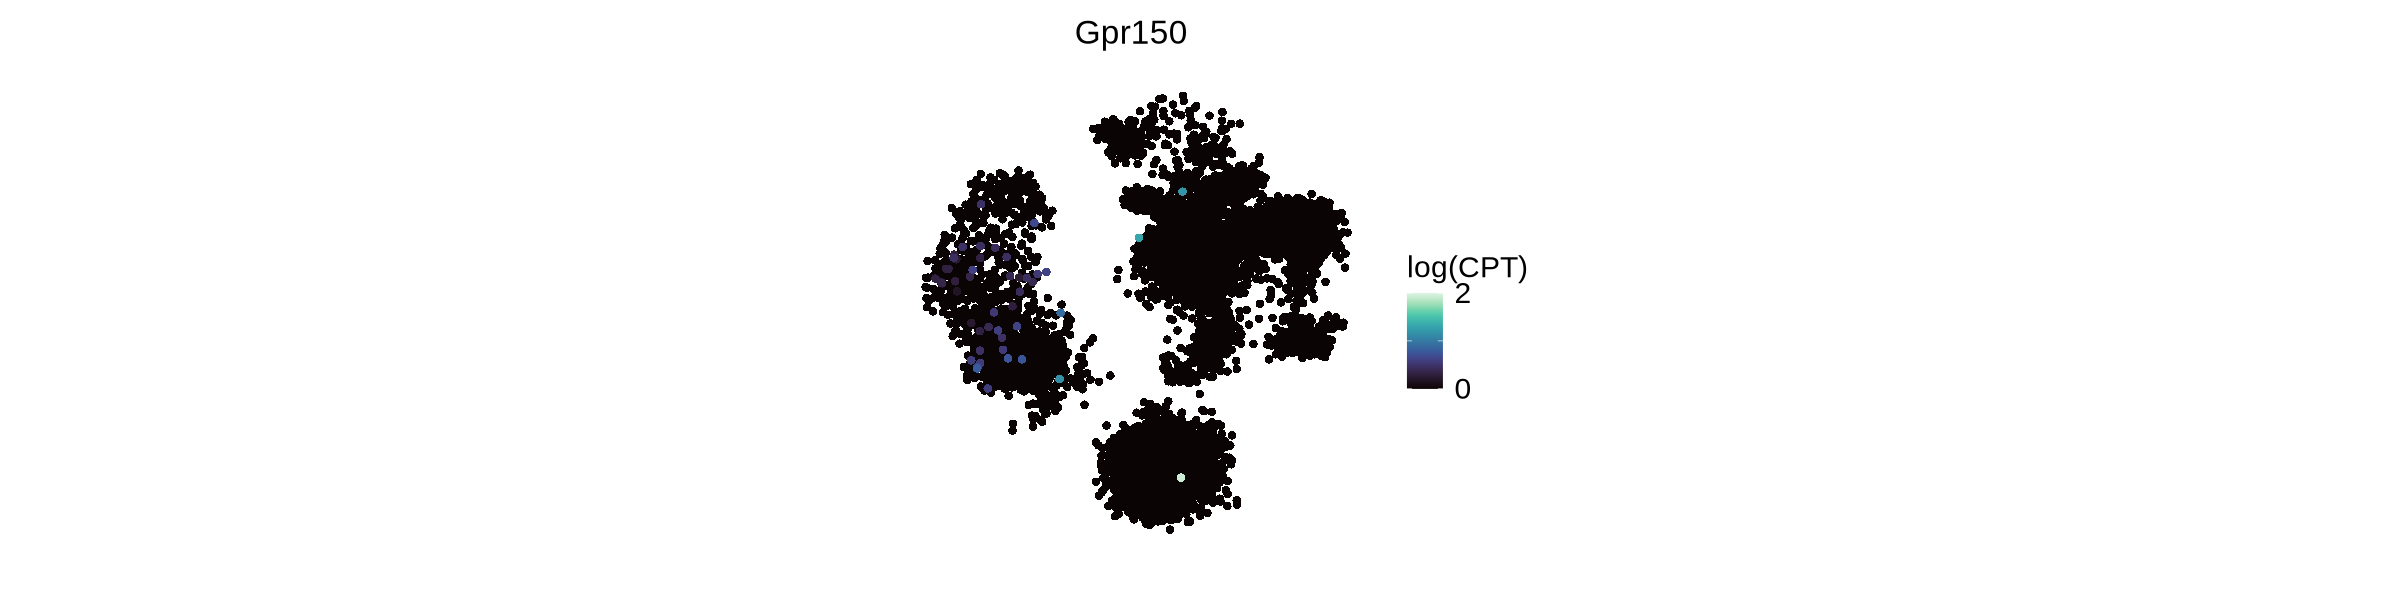

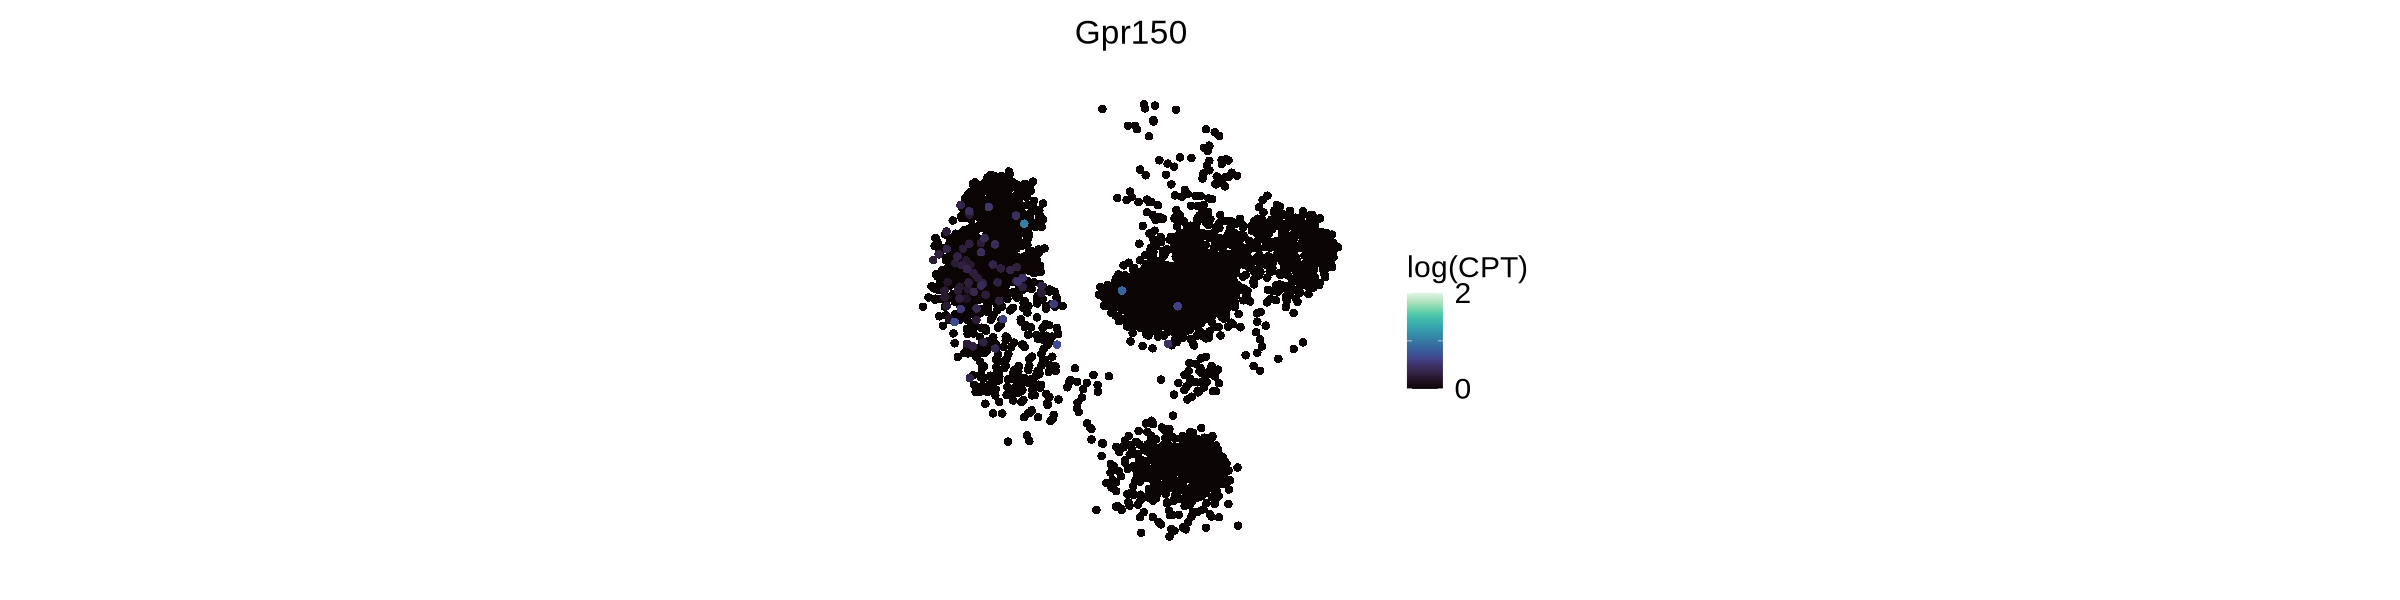

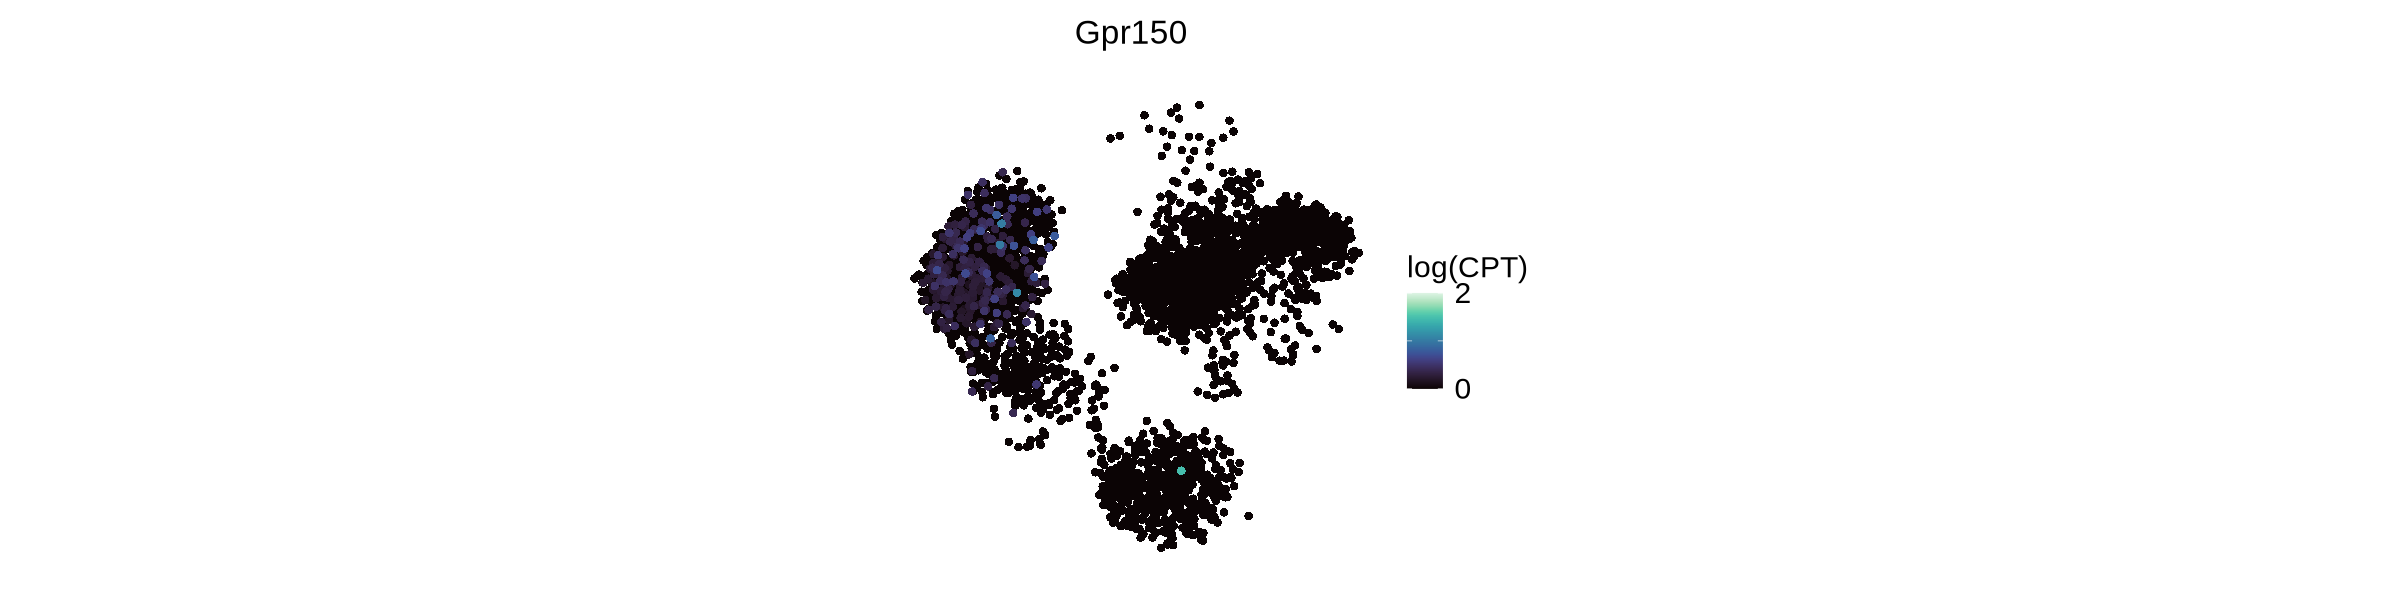

In [133]:
fplot(so[, so$dpi=="D0"], features="Gpr150", slot="data")
fplot(so[, so$dpi=="D3" & so$genotype=="IFNAR_fl"], features="Gpr150", slot="data")
fplot(so[, so$dpi=="D3" & so$genotype=="IFNAR_fl_LysM_cre"], features="Gpr150", slot="data")

## Stress erythroid progenitor marker genes 

In [134]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "solid", "solid"), contrast_vec)

In [135]:
genes <- c("Kit", "Cd34", "Cd24a", "Tfrc", "Slamf1", "Cd9", "Ly6a")

In [136]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

ERROR: Error in assays(fitgam)$counts[gene, , drop = FALSE]: subscript out of bounds


In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_sep_marker_ctl_vs_d1.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "dashed", "dashed"), contrast_vec)

In [ ]:
genes <- c("Kit", "Cd34", "Cd24a", "Tfrc", "Slamf1", "Cd9", "Ly6a")

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_sep_marker_ctl_vs_d3.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

## Surface receptors 

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "solid", "solid"), contrast_vec)

In [ ]:
genes <- c("Ifnar1", "Ifnar2", "Ifngr1", "Ifngr2", "H2-Ab1", "H2-Aa", "H2-Eb1", "Ciita", "Bmpr1a", "Bmpr1b", "Bmpr2", "Tgfbr1", "Tgfbr2", "Tgfbr3", "Kit", "Epor", "Lifr", "Osmr", "Csf2rb", "Cntfr", "Il6st", "Il6ra", "Il11ra1", "Tnfrsf1a", "Tnfrsf1b", "Il1r1", "Il1r2", "Irf1")
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_receptor_ctl_vs_d1.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "dashed", "dashed"), contrast_vec)

In [ ]:
genes <- c("Ifnar1", "Ifnar2", "Ifngr1", "Ifngr2", "H2-Ab1", "H2-Aa", "H2-Eb1", "Ciita", "Bmpr1a", "Bmpr1b", "Bmpr2", "Tgfbr1", "Tgfbr2", "Tgfbr3", "Kit", "Epor", "Lifr", "Osmr", "Csf2rb", "Cntfr", "Il6st", "Il6ra", "Il11ra1", "Tnfrsf1a", "Tnfrsf1b", "Il1r1", "Il1r2", "Irf1")
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_receptor_ctl_vs_d3.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

## Oxidative phosphorilation 

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "solid", "solid"), contrast_vec)

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION|AEROBIC", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_oxphos_ctl_vs_d1.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[contrast_vec]
condition_line_type <- setNames(c("solid", "solid", "dashed", "dashed"), contrast_vec)

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION|AEROBIC", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_oxphos_ctl_vs_d3.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

## Selected genes 

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")]
condition_line_type <- setNames(c("solid", "solid", "solid", "solid"), contrast_vec)

In [ ]:
genes <- c(

    # D1 and D3 UP
    "Myd88", # TLR and Ilr1 activation
    "Cd9", # Stress erythropoiesis marker 
    "Lyl1", # Stress erythroid marker 
    "Serpina3g",  # Protect from cell death. Especially Serpina3g has konwn roles in erythropoiesis 
    "App", # Cell cycle
    "Atp10a", # AP4 flippase
    "G6pdx", # PPP
    "Got1", "Acot9", "Atp10a", # Fatty acid metabolism 
    "Ldlrap1", "Lrp8", "Ffar2", # LDL receptor 
    "Pfkp", # Glucose
    "Scly", # Selenium metabolism 

    "Irak1", "Irak2", "Irak4", "Unc93b1", # Mydosome 
    "Ifnar1", "Ifnar2", "Ifngr1", "Ifngr2", "Il1rl1", "Il1rap", # IL1 family receptor
    "Isg15", "Oas3", "Isg20", "Ifi27", "Ifi27l2a", "Ifi35", "Trim25", # Type I interferon (ALL up)
    "Nlrc5", "H2-K1", "Tap2", "Psmb8", "Psmb10", "Psme1", "Psme2", "Erap1", # MHC I presentation (All up)
    "Ciita", "Cd74", "H2-Aa", "H2-Ab1", "H2-Eb1", # MHC II presentation (All up)
    "Nfkb1", "Rela", "Rel", "Nfkbib", # Nfkb1 is canonical 

    "Mxd4", "Deptor", "Txnip", "Pdcd4", 
    "Cox6b2", "Prkn", 

    "Gpr150", 
    "Cpd", 
    "Erfe",
    "Cish", 
    "Podxl",
    "Irs2", 

    "Stat1", "Stat2", "Stat3", 
    "Irf1", "Irf7",  
    "Ifih1", "Ifitm3", "Ifi44", "Ifi47", 
    "Usp18", "Socs1", 
    "Ube2l6", "Uba7", # ISGylation E2 and ISGylation E1
    "Mndal", # Suppresses cell growth and proliferation.
    "Nampt", # Increases NAD⁺ availability supports glycolysis, PPP flux, redox balance
    "Lipe", # Supports lipid remodeling during proliferation
    "Irf9", 
    "Nfkbia", "Nfkbid", "Tnfsf10", # TRAIL - NF-kB and type I inducable 
    "Gbp2", "Gbp3", "Gbp4", "Gbp5", "Gbp6", "Gbp7", "Gbp8", "Irgm2", "Iigp1", 
    
    
    "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb",  
    "Cd69", "Gem", # Not sure
    "Ier2", "Ier5", "Egr1", # Rise fast after MAPK signaling (growth factors, cytokines, TLR/TNF)
    "Zfp36", "Dusp1", # Turns down inflammatory drive
    "Mxd1", "Klf6", # Myc antagonist and negativ regulator of erythropoiesis
    "Mecom", # Maintain HSC and maybe blocks erythropoiesis
    "Tnfaip3" # Suppresses NF-κB-driven inflammatory differentiation cues
    
)

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_ptag_ctl_ctlko_d1_d1ko.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

In [ ]:
contrast_vec <- c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")
color_mat <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]
condition_line_type <- setNames(c("solid", "solid", "dashed", "dashed"), contrast_vec)

In [ ]:
genes <- c(

    # D1 and D3 UP
    "Myd88", # TLR and Ilr1 activation
    "Cd9", # Stress erythropoiesis marker 
    "Lyl1", # Stress erythroid marker 
    "Serpina3g",  # Protect from cell death. Especially Serpina3g has konwn roles in erythropoiesis 
    "App", # Cell cycle
    "Atp10a", # AP4 flippase
    "G6pdx", # PPP
    "Got1", "Acot9", "Atp10a", # Fatty acid metabolism 
    "Ldlrap1", "Lrp8", "Ffar2", # LDL receptor 
    "Pfkp", # Glucose
    "Scly", # Selenium metabolism 

    "Irak1", "Irak2", "Irak4", "Unc93b1", # Mydosome 
    "Ifnar1", "Ifnar2", "Ifngr1", "Ifngr2", "Il1rl1", "Il1rap", # IL1 family receptor
    "Isg15", "Oas3", "Isg20", "Ifi27", "Ifi27l2a", "Ifi35", "Trim25", # Type I interferon (ALL up)
    "Nlrc5", "H2-K1", "Tap2", "Psmb8", "Psmb10", "Psme1", "Psme2", "Erap1", # MHC I presentation (All up)
    "Ciita", "Cd74", "H2-Aa", "H2-Ab1", "H2-Eb1", # MHC II presentation (All up)
    "Nfkb1", "Rela", "Rel", "Nfkbib", # Nfkb1 is canonical 

    "Mxd4", "Deptor", "Txnip", "Pdcd4", 
    "Cox6b2", "Prkn", 

    "Gpr150", 
    "Cpd", 
    "Erfe",
    "Cish", 
    "Podxl",
    "Irs2", 

    "Stat1", "Stat2", "Stat3", 
    "Irf1", "Irf7",  
    "Ifih1", "Ifitm3", "Ifi44", "Ifi47", 
    "Usp18", "Socs1", 
    "Ube2l6", "Uba7", # ISGylation E2 and ISGylation E1
    "Mndal", # Suppresses cell growth and proliferation.
    "Nampt", # Increases NAD⁺ availability supports glycolysis, PPP flux, redox balance
    "Lipe", # Supports lipid remodeling during proliferation
    "Irf9", 
    "Nfkbia", "Nfkbid", "Tnfsf10", # TRAIL - NF-kB and type I inducable 
    "Gbp2", "Gbp3", "Gbp4", "Gbp5", "Gbp6", "Gbp7", "Gbp8", "Irgm2", "Iigp1", 
    
    
    "Atf3", "Jun", "Junb", "Jund", "Fos", "Fosb",  
    "Cd69", "Gem", # Not sure
    "Ier2", "Ier5", "Egr1", # Rise fast after MAPK signaling (growth factors, cytokines, TLR/TNF)
    "Zfp36", "Dusp1", # Turns down inflammatory drive
    "Mxd1", "Klf6", # Myc antagonist and negativ regulator of erythropoiesis
    "Mecom", # Maintain HSC and maybe blocks erythropoiesis
    "Tnfaip3" # Suppresses NF-κB-driven inflammatory differentiation cues
    
)

In [ ]:
lp_1 <- lapply(genes, function(i) {plot_smooth(fitgam, gene=i, point=FALSE, condition_color=color_mat, line_size=unit(1.5/2.141959, "pt"), condition_line_type=condition_line_type, y_scale_full=TRUE) + annotate("text", x=0.5, y=0, label=i, hjust=0.5, vjust=-1, size=2) + theme(legend.position="none")})
lp_1 <- lapply(lp_1, function(p) egg::set_panel_size(p, width=unit(2.0, "cm"), height=unit(0.75, "cm")))
lp_1 <- do.call(gridExtra::arrangeGrob, c(lp_1, ncol=10, nrow=ceiling(length(lp_1)/10)))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/lp_ptag_ctl_ctlko_d3_d3ko.pdf", width=10*1.25, height=ceiling(length(lp_1)/10))

grid::grid.draw(lp_1)

dev.off()

In [ ]:
fplot(so[, so$dpi=="D3" & so$genotype=="IFNAR_fl"], features="Gpr150", slot="data")
fplot(so[, so$dpi=="D3" & so$genotype=="IFNAR_fl_LysM_cre"], features="Gpr150", slot="data")

# Pie chart PT gene counts

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_1 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_1 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs D1 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_2 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_2 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs D3 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_3 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_3 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (+/+) vs D3 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_4 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_4 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (cre/+) vs D1 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_5 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_5 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (cre/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_6 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_6 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (cre/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_7 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_7 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs Ctl (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_8 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_8 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (+/+) vs D1 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- c("Perturbed"="#7f7f7f", "Canonical"="#AEAEAE")
data <- table(ptpg_res_9 %>% dplyr::mutate(ptpg_class=ifelse(ptpg_class=="Canonical", "Canonical", "Perturbed")) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color)))
data
p_pl_9 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D3 (+/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/pie_pl_pt_class.pdf", width=15, height=5)

gridExtra::grid.arrange(
    
    p_pl_1 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_2 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_3 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_4 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_5 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_6 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_7 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_8 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_9 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    ncol=3
    
)

dev.off()

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D1")]

data <- table(ptpg_res_1 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_1 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs D1 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_CpG_D3")]

data <- table(ptpg_res_2 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_2 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs D3 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_CpG_D1", "IFNAR_fl_CpG_D3")]
ptpg_class_color[2] <- scales::alpha(ptpg_class_color[2], 0.5)

data <- table(ptpg_res_3 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_3 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (+/+) vs D3 (+/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D1")]

data <- table(ptpg_res_4 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_4 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (cre/+) vs D1 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_LysM_cre_Baseline_D0", "IFNAR_fl_LysM_cre_CpG_D3")]

data <- table(ptpg_res_5 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_5 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (cre/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_LysM_cre_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D3")]
ptpg_class_color[2] <- scales::alpha(ptpg_class_color[2], 0.5)

data <- table(ptpg_res_6 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_6 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (cre/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_Baseline_D0", "IFNAR_fl_LysM_cre_Baseline_D0")]

data <- table(ptpg_res_7 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_7 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("Ctr (+/+) vs Ctl (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_CpG_D1", "IFNAR_fl_LysM_cre_CpG_D1")]

data <- table(ptpg_res_8 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_8 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D1 (+/+) vs D1 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
ptpg_class_color <- color$sample_group[c("IFNAR_fl_CpG_D3", "IFNAR_fl_LysM_cre_CpG_D3")]

data <- table(ptpg_res_9 %>% dplyr::filter(ptpg_class %in% names(ptpg_class_color)) %>% dplyr::pull(ptpg_class)) %>% data.frame() %>% dplyr::rename(group=Var1, count=Freq) %>% dplyr::mutate(group=factor(group, levels=names(ptpg_class_color))) %>% na.omit()
data
p_pl_9 <- ggplot(data, aes(x="", y=count, fill=group)) +
    geom_col(width=1) +
    coord_polar(theta="y") + 
    scale_fill_manual(values=ptpg_class_color) + 
    ggtitle("D3 (+/+) vs D3 (cre/+)") + 
    guides(fill=guide_legend(ncol=1, override.aes=list(alpha=1, size=1.5), keywidth=0.25, keyheight=0.25, default.unit="cm"))

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/pie_pl_ptpg_class.pdf", width=15, height=5)

gridExtra::grid.arrange(
    
    p_pl_1 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_2 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_3 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_4 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_5 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_6 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_7 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_8 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    p_pl_9 %>% egg::set_panel_size(., width=unit(2.5, "cm"), height=unit(2.5, "cm")), 
    ncol=3
    
)

dev.off()

# Protein-Protein interaction 

In [ ]:
# Create STRING DB for mouse 
string_db <- STRINGdb::STRINGdb$new(version="12.0", species=10090, score_threshold=400, network_type="full", link_data="combined_only")

## OXPHOS D1 +/+

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
# Mapp DEA results to STRING DB
string_db_dea <- ptpg_res_1 %>% dplyr::filter(gene %in% genes) %>% dplyr::select(gene, log2FC_wilcox, p_val_adj_wald) %>% dplyr::rename(logFC=log2FC_wilcox, padj=p_val_adj_wald) %>% string_db$map(., "gene", removeUnmappedRows=TRUE) 

In [ ]:
# Labe PPI vertices 
ppi_v <- string_db_dea %>% dplyr::distinct() %>% dplyr::rename(name=STRING_id) %>% 
    dplyr::group_by(name) %>% dplyr::mutate(n=n()) %>% dplyr::filter(n==1) %>% dplyr::select(name, gene, logFC, padj) %>% 
    dplyr::mutate(node_group=ifelse(padj<=0.05 & logFC<=-0.50, "neg", ifelse(padj<=0.05 & logFC>=0.50, "pos", "n.s."))) %>%
    dplyr::mutate(node_group=factor(node_group, levels=rev(c("n.s.", "neg", "pos"))))

In [ ]:
# Create PPI edges from DEA PPI
ppi_e <- string_db$get_interactions(string_db_dea$STRING_id)

In [ ]:
# Compute igraph object
g <- igraph::graph_from_data_frame(
    
    d=ppi_e,
    vertices=ppi_v, 
    directed=FALSE

)

In [ ]:
# Connected components 
min_component_size <- 2  # keep components with >= 4 vertices

g_components <- igraph::components(g)
g <- igraph::delete_vertices(g, which(g_components$csize[g_components$membership] < min_component_size))

In [ ]:
# Set weights
E(g)$weight <- E(g)$combined_score

In [ ]:
v_label <- tidygraph::as_tbl_graph(g) %>% as.data.frame() %>% dplyr::filter(node_group!="n.s.") %>% pull(gene)

In [ ]:
# Plot graph 
g_1 <- tidygraph::as_tbl_graph(g) %>%  
    ggraph::ggraph(., layout="fr", weights=weight) +
    geom_edge_link(alpha=0.2, width=0.1, color="#000000") +
    geom_node_point(aes(fill=node_group , size=abs(logFC)), color="black", shape=21, stroke=0.1) +
    geom_node_text(aes(label=ifelse(gene %in% v_label, gene, NA)), repel=FALSE, size=2.1, color="black") + 
    scale_fill_manual(values=c("pos"="#cd34b5", "n.s."="#7f7f7f", "neg"="#66c2a5")) +
    scale_size_continuous(range=c(0.5, 3)) + 
    theme(aspect.ratio=1) + theme_global_set(4)

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/string_d1_cg_oxphos.pdf", width=10, height=10)

gridExtra::grid.arrange(egg::set_panel_size(g_1, width=unit(2.5, "cm"), height=unit(2.5, "cm")))

dev.off()

## OXPHOS D3 +/+

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
# Mapp DEA results to STRING DB
string_db_dea <- ptpg_res_2 %>% dplyr::filter(gene %in% genes) %>% dplyr::select(gene, log2FC_wilcox, p_val_adj_wald) %>% dplyr::rename(logFC=log2FC_wilcox, padj=p_val_adj_wald) %>% string_db$map(., "gene", removeUnmappedRows=TRUE) 

In [ ]:
# Labe PPI vertices 
ppi_v <- string_db_dea %>% dplyr::distinct() %>% dplyr::rename(name=STRING_id) %>% 
    dplyr::group_by(name) %>% dplyr::mutate(n=n()) %>% dplyr::filter(n==1) %>% dplyr::select(name, gene, logFC, padj) %>% 
    dplyr::mutate(node_group=ifelse(padj<=0.05 & logFC<=-0.50, "neg", ifelse(padj<=0.05 & logFC>=0.50, "pos", "n.s.")))

In [ ]:
# Create PPI edges from DEA PPI
ppi_e <- string_db$get_interactions(string_db_dea$STRING_id)

In [ ]:
# Compute igraph object
g <- igraph::graph_from_data_frame(
    
    d=ppi_e,
    vertices=ppi_v, 
    directed=FALSE

)

In [ ]:
# Connected components 
min_component_size <- 2  # keep components with >= 4 vertices

g_components <- igraph::components(g)
g <- igraph::delete_vertices(g, which(g_components$csize[g_components$membership] < min_component_size))

In [ ]:
# Set weights
E(g)$weight <- E(g)$combined_score

In [ ]:
v_label <- tidygraph::as_tbl_graph(g) %>% as.data.frame() %>% dplyr::filter(node_group!="n.s.") %>% pull(gene)

In [ ]:
# Plot graph 
g_1 <- tidygraph::as_tbl_graph(g) %>%  
    ggraph::ggraph(., layout="fr", weights=weight) +
    geom_edge_link(alpha=0.2, width=0.1, color="#000000") +
    geom_node_point(aes(fill=node_group , size=abs(logFC)), color="black", shape=21, stroke=0.1) +
    geom_node_text(aes(label=ifelse(gene %in% v_label, gene, NA)), repel=FALSE, size=2.1, color="black") + 
    scale_fill_manual(values=c("pos"="#cd34b5", "n.s."="#7f7f7f", "neg"="#66c2a5")) +
    scale_size_continuous(range=c(0.5, 3)) + 
    theme(aspect.ratio=1) + theme_global_set(4)

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/string_d3_cg_oxphos.pdf", width=10, height=10)

gridExtra::grid.arrange(egg::set_panel_size(g_1, width=unit(2.5, "cm"), height=unit(2.5, "cm")))

dev.off()

## OXPHOS D1 cre/+

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
# Mapp DEA results to STRING DB
string_db_dea <- ptpg_res_4 %>% dplyr::filter(gene %in% genes) %>% dplyr::select(gene, log2FC_wilcox, p_val_adj_wald) %>% dplyr::rename(logFC=log2FC_wilcox, padj=p_val_adj_wald) %>% string_db$map(., "gene", removeUnmappedRows=TRUE) 

In [ ]:
# Labe PPI vertices 
ppi_v <- string_db_dea %>% dplyr::distinct() %>% dplyr::rename(name=STRING_id) %>% 
    dplyr::group_by(name) %>% dplyr::mutate(n=n()) %>% dplyr::filter(n==1) %>% dplyr::select(name, gene, logFC, padj) %>% 
    dplyr::mutate(node_group=ifelse(padj<=0.05 & logFC<=-0.50, "neg", ifelse(padj<=0.05 & logFC>=0.50, "pos", "n.s.")))

In [ ]:
# Create PPI edges from DEA PPI
ppi_e <- string_db$get_interactions(string_db_dea$STRING_id)

In [ ]:
# Compute igraph object
g <- igraph::graph_from_data_frame(
    
    d=ppi_e,
    vertices=ppi_v, 
    directed=FALSE

)

In [ ]:
# Connected components 
min_component_size <- 2  # keep components with >= 4 vertices

g_components <- igraph::components(g)
g <- igraph::delete_vertices(g, which(g_components$csize[g_components$membership] < min_component_size))

In [ ]:
# Set weights
E(g)$weight <- E(g)$combined_score

In [ ]:
v_label <- tidygraph::as_tbl_graph(g) %>% as.data.frame() %>% dplyr::filter(node_group!="n.s.") %>% pull(gene)

In [ ]:
# Plot graph 
g_1 <- tidygraph::as_tbl_graph(g) %>% ggraph::ggraph(., layout="fr") +
    geom_edge_link(alpha=0.2, width=0.1, color="#000000") +
    geom_node_point(aes(fill=node_group , size=abs(logFC)), color="black", shape=21, stroke=0.1) +
    geom_node_text(aes(label=ifelse(gene %in% v_label, gene, NA)), repel=FALSE, size=2.1, color="black") + 
    scale_fill_manual(values=c("neg"="#66c2a5", "n.s."="#7f7f7f", "pos"="#cd34b5")) +
    scale_size_continuous(range=c(0.5, 3)) + 
    theme(aspect.ratio=1) + theme_global_set(4)

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/string_d1_ko_oxphos.pdf", width=10, height=10)

gridExtra::grid.arrange(egg::set_panel_size(g_1, width=unit(2.5, "cm"), height=unit(2.5, "cm")))

dev.off()

## OXPHOS D3 cre/+

In [ ]:
genes <- gene_set %>% dplyr::filter(gs_name %in% grep("OXIDATIVE_PHOSPHORYLATION", gs_name, value=TRUE)) %>% dplyr::pull(gene_symbol) %>% unique()
genes <- genes[genes %in% rownames(fitgam)]

In [ ]:
# Mapp DEA results to STRING DB
string_db_dea <- ptpg_res_5 %>% dplyr::filter(gene %in% genes) %>% dplyr::select(gene, log2FC_wilcox, p_val_adj_wald) %>% dplyr::rename(logFC=log2FC_wilcox, padj=p_val_adj_wald) %>% string_db$map(., "gene", removeUnmappedRows=TRUE) 

In [ ]:
# Labe PPI vertices 
ppi_v <- string_db_dea %>% dplyr::distinct() %>% dplyr::rename(name=STRING_id) %>% 
    dplyr::group_by(name) %>% dplyr::mutate(n=n()) %>% dplyr::filter(n==1) %>% dplyr::select(name, gene, logFC, padj) %>% 
    dplyr::mutate(node_group=ifelse(padj<=0.05 & logFC<=-0.50, "neg", ifelse(padj<=0.05 & logFC>=0.50, "pos", "n.s.")))

In [ ]:
# Create PPI edges from DEA PPI
ppi_e <- string_db$get_interactions(string_db_dea$STRING_id)

In [ ]:
# Compute igraph object
g <- igraph::graph_from_data_frame(
    
    d=ppi_e,
    vertices=ppi_v, 
    directed=FALSE

)

In [ ]:
# Connected components 
min_component_size <- 2  # keep components with >= 4 vertices

g_components <- igraph::components(g)
g <- igraph::delete_vertices(g, which(g_components$csize[g_components$membership] < min_component_size))

In [ ]:
# Set weights
E(g)$weight <- E(g)$combined_score

In [ ]:
v_label <- tidygraph::as_tbl_graph(g) %>% as.data.frame() %>% dplyr::filter(node_group!="n.s.") %>% pull(gene)

In [ ]:
# Plot graph 
g_1 <- tidygraph::as_tbl_graph(g) %>% ggraph::ggraph(., layout="fr") +
    geom_edge_link(alpha=0.2, width=0.1, color="#000000") +
    geom_node_point(aes(fill=node_group , size=abs(logFC)), color="black", shape=21, stroke=0.1) +
    geom_node_text(aes(label=ifelse(gene %in% v_label, gene, NA)), repel=FALSE, size=2.1, color="black") + 
    scale_fill_manual(values=c("neg"="#66c2a5", "n.s."="#7f7f7f", "pos"="#cd34b5")) +
    scale_size_continuous(range=c(0.5, 3)) + 
    theme(aspect.ratio=1) + theme_global_set(4)

In [ ]:
pdf("result/figures/1_scRNAseq/panel_6/string_d3_ko_oxphos.pdf", width=10, height=10)

gridExtra::grid.arrange(egg::set_panel_size(g_1, width=unit(2.5, "cm"), height=unit(2.5, "cm")))

dev.off()